# Clasificación de Personajes de Los Simpsons

## Introducción y Entorno

En este trabajo desarrollaremos un modelo de Deep Learning basado en Redes Neuronales Convolucionales (CNN) para clasificar imágenes de personajes de la serie animada Los Simpsons.

Comenzamos importando las librerías necesarias. Además de las librerías estándar de manipulación de datos y visualización, utilizaremos PyTorch y PyTorch Lightning para la creación y entrenamiento del modelo. Haremos uso de tres módulos personalizados ubicados en la carpeta src que encapsulan la carga de datos, el ciclo de entrenamiento y las funciones visuales.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning.pytorch.loggers import CSVLogger
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import torchvision.datasets as datasets
from torchinfo import summary

# Módulos propios
from src.data import SimpsonsDataModule
from src.lightning_module import SimpsonsModule
from src.visualization import evaluate_model

# Variables Globales
DATA_DIR = '../data'
SIMPSONS_DIR = os.path.join(DATA_DIR, 'simpsons')


## Análisis Exploratorio de Datos Inicial

Antes de configurar nuestro flujo de Deep Learning, necesitamos analizar el estado de los datos originales.
Realizaremos un escaneo de la carpeta de imágenes para evaluar la cantidad total de imágenes y el balance de las clases. Esto nos permitirá detectar problemas de falta de ejemplos (Few-Shot Learning) y tomar decisiones sobre el filtrado de clases minoritarias.

Total de imágenes originales: 20933
Total de clases originales: 42

Top 5 Clases Mayoritarias:


,Personaje,Cantidad,Proporcion (%)
0,homer_simpson,2246,10.73
1,ned_flanders,1454,6.95
2,moe_szyslak,1452,6.94
3,lisa_simpson,1354,6.47
4,bart_simpson,1342,6.41



Top 5 Clases Minoritarias:


,Personaje,Cantidad,Proporcion (%)
37,fat_tony,27,0.13
38,miss_hoover,17,0.08
39,disco_stu,8,0.04
40,troy_mcclure,8,0.04
41,lionel_hutz,3,0.01


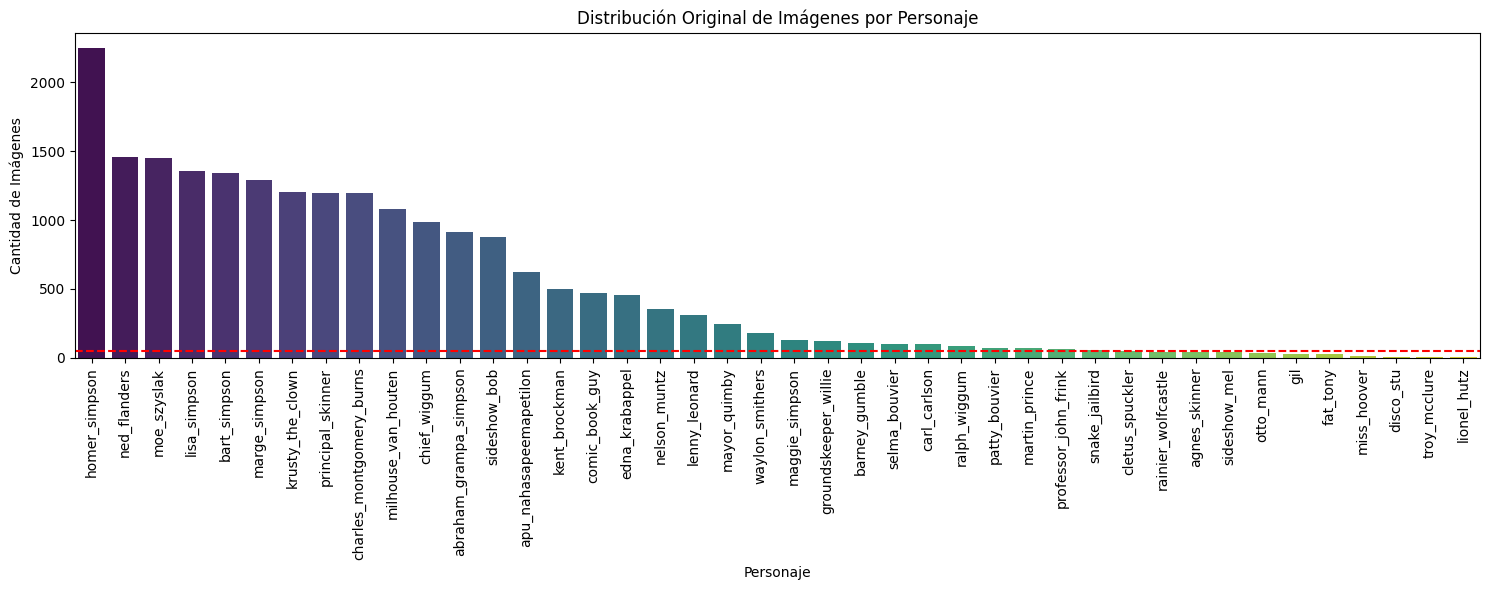

In [2]:
# Extraer la distribución original de clases
raw_ds = datasets.ImageFolder(SIMPSONS_DIR)
from collections import Counter
counts = Counter([label for _, label in raw_ds.samples])

class_counts = {raw_ds.classes[label]: count for label, count in counts.items()}
df_raw = pd.DataFrame(list(class_counts.items()), columns=['Personaje', 'Cantidad'])
df_raw = df_raw.sort_values('Cantidad', ascending=False).reset_index(drop=True)

total_images = df_raw['Cantidad'].sum()
df_raw['Proporcion (%)'] = (df_raw['Cantidad'] / total_images * 100).round(2)

print(f"Total de imágenes originales: {total_images}")
print(f"Total de clases originales: {len(df_raw)}")
print("\nTop 5 Clases Mayoritarias:")
display(df_raw.head())
print("\nTop 5 Clases Minoritarias:")
display(df_raw.tail())

plt.figure(figsize=(15, 6))
sns.barplot(data=df_raw, x='Personaje', y='Cantidad', hue='Personaje', palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Distribución Original de Imágenes por Personaje')
plt.axhline(50, color='red', linestyle='--', label='Umbral de filtrado (50)')
plt.ylabel('Cantidad de Imágenes')
plt.xlabel('Personaje')
plt.tight_layout()
plt.show()


## Toma de Decisiones sobre los Datos

Como se observa en el análisis, enfrentamos un problema de desbalance extremo. Algunos personajes, como Lionel Hutz, poseen menos de 10 imágenes. Intentar entrenar a una red neuronal convolucional para que aprenda a generalizar un rostro con tan pocos ejemplos es inviable matemáticamente y contaminaría las métricas globales del modelo.

Por lo tanto, la capa de datos descarta automáticamente cualquier personaje que posea menos de 50 imágenes. Esto nos consolida un dataset de clases sólidas que son verdaderamente aptas para el entrenamiento.

## Configuración y Pipeline de Datos

Definimos nuestros hiperparámetros de experimentación en una clase estática. Posteriormente, inicializamos nuestro módulo de datos, el cual aplicará el filtrado de clases, la aumentación y realizará la partición estratificada de los datos.

In [3]:
@dataclass
class Config:
    in_channels: int = 3
    image_size: int = 64
    batch_size: int = 128
    lr: float = 1e-3
    weight_decay: float = 1e-4
    data_dir: str = '../data'

cfg = Config()

datamodule = SimpsonsDataModule(cfg)
datamodule.prepare_data()
datamodule.setup()



[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


## Análisis Exploratorio Post-Split

Tras ejecutar la partición, es importante comprobar cómo quedaron conformados los subconjuntos de Entrenamiento, Validación y Prueba. Analizaremos las cantidades y observaremos si la estratificación se aplicó correctamente para todas las clases que superaron el umbral.

Total imágenes Train: 14858
Total imágenes Val: 1651
Total imágenes Test: 4128


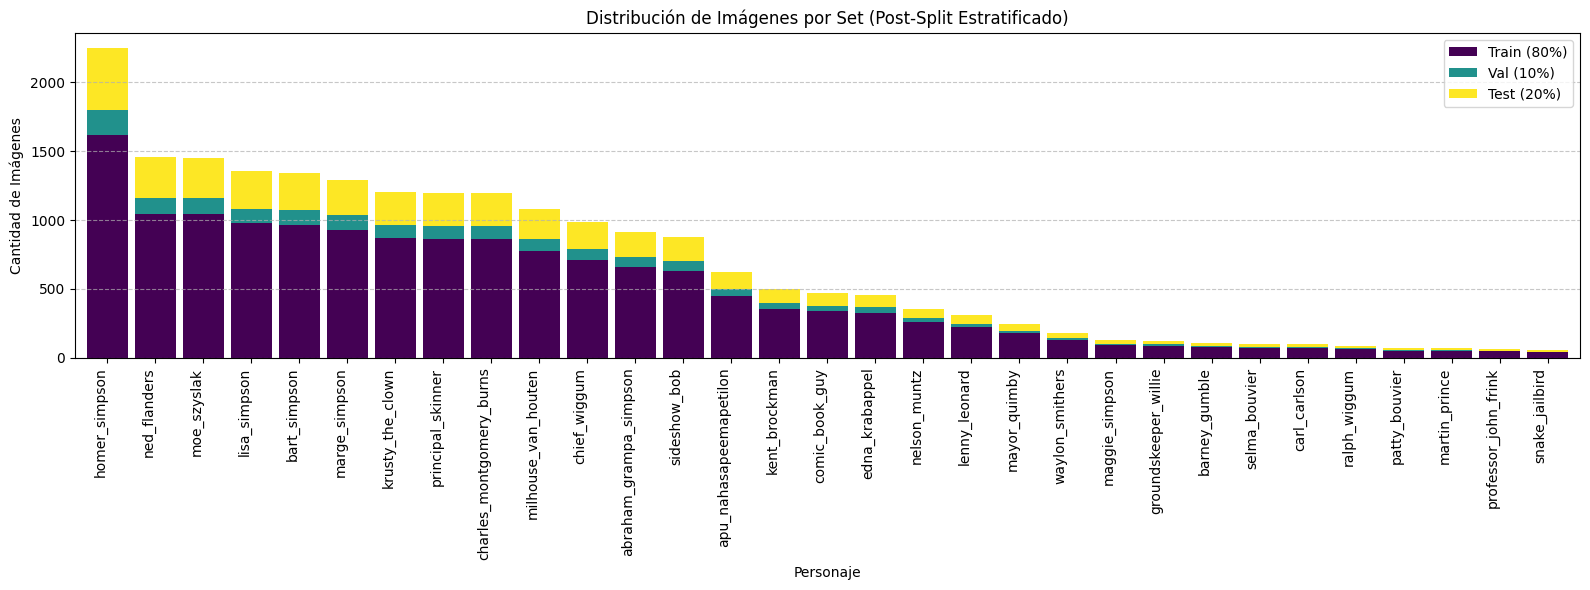

In [4]:
# Obtener conteos de las clases en cada subset resultante
train_counts = Counter([y for _, y in datamodule.train_ds])
val_counts = Counter([y for _, y in datamodule.val_ds])
test_counts = Counter([y for _, y in datamodule.test_ds])

idx_to_class = {i: k for i, k in enumerate(datamodule.classes)}
data_split = []
for idx in idx_to_class.keys():
    name = idx_to_class[idx]
    tr, va, te = train_counts.get(idx, 0), val_counts.get(idx, 0), test_counts.get(idx, 0)
    total = tr + va + te
    data_split.append({
        "Personaje": name, 
        "Train (80%)": tr, 
        "Val (10%)": va, 
        "Test (20%)": te,
        "Total": total
    })

df_split = pd.DataFrame(data_split).set_index("Personaje").sort_values("Total", ascending=False)

print(f"Total imágenes Train: {df_split['Train (80%)'].sum()}")
print(f"Total imágenes Val: {df_split['Val (10%)'].sum()}")
print(f"Total imágenes Test: {df_split['Test (20%)'].sum()}")

ax = df_split[["Train (80%)", "Val (10%)", "Test (20%)"]].plot(
    kind="bar", stacked=True, figsize=(16, 6), colormap="viridis", width=0.85
)
plt.title("Distribución de Imágenes por Set (Post-Split Estratificado)")
plt.ylabel("Cantidad de Imágenes")
plt.xlabel("Personaje")
plt.xticks(rotation=90, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Arquitectura del Modelo

A continuación, definimos desde cero nuestra Red Neuronal Convolucional (CNN).
Diseñaremos una arquitectura secuencial con bloques convolucionales que incluyen capas de normalización (Batch Normalization) para estabilizar el aprendizaje, y capas de MaxPooling para reducir la dimensionalidad. Al final, usaremos Global Average Pooling seguido de un regularizador Dropout para minimizar el riesgo de sobreajuste.

In [5]:
class CNN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, dropout_rate: float = 0.5):
        super().__init__()
        
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloque 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Clasificador
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instanciamos la arquitectura
cnn_model = CNN(in_channels=cfg.in_channels, num_classes=datamodule.num_classes)

summary(cnn_model, input_size=(cfg.batch_size, cfg.in_channels, cfg.image_size, cfg.image_size))


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [128, 31]                 --
├─Sequential: 1-1                        [128, 256, 4, 4]          --
│    └─Conv2d: 2-1                       [128, 32, 64, 64]         896
│    └─BatchNorm2d: 2-2                  [128, 32, 64, 64]         64
│    └─ReLU: 2-3                         [128, 32, 64, 64]         --
│    └─MaxPool2d: 2-4                    [128, 32, 32, 32]         --
│    └─Conv2d: 2-5                       [128, 64, 32, 32]         18,496
│    └─BatchNorm2d: 2-6                  [128, 64, 32, 32]         128
│    └─ReLU: 2-7                         [128, 64, 32, 32]         --
│    └─MaxPool2d: 2-8                    [128, 64, 16, 16]         --
│    └─Conv2d: 2-9                       [128, 128, 16, 16]        73,856
│    └─BatchNorm2d: 2-10                 [128, 128, 16, 16]        256
│    └─ReLU: 2-11                        [128, 128, 16, 16]        --
│   

## Entrenamiento

Con la arquitectura construida y el pipeline de datos preparado, procedemos a entrenar el modelo. Emplearemos PyTorch Lightning como orquestador, el cual manejará los bucles de entrenamiento y validación de forma automática.
Compilamos nuestra red dentro de nuestro LightningModule personalizado y corremos el proceso durante 10 épocas.

In [6]:
# Compilamos el modelo en PyTorch Lightning
lightning_model = SimpsonsModule(cfg, model=cnn_model, num_classes=datamodule.num_classes)

# Inicializamos el orquestador
trainer = L.Trainer(
    max_epochs=10,
    accelerator="auto",
    enable_checkpointing=False,
    logger=CSVLogger("logs", name="cnn_model")
)

# Ejecutamos el entrenamiento
trainer.fit(lightning_model, datamodule=datamodule)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.



[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).



  | Name           | Type                | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0 | model          | CNN                 | 397 K  | train | 0    
1 | train_acc      | MulticlassAccuracy  | 0      | train | 0    
2 | val_acc        | MulticlassAccuracy  | 0      | train | 0    
3 | val_f1         | MulticlassF1Score   | 0      | train | 0    
4 | test_acc       | MulticlassAccuracy  | 0      | train | 0    
5 | test_f1        | MulticlassF1Score   | 0      | train | 0    
6 | test_precision | MulticlassPrecision | 0      | train | 0    
7 | test_recall    | MulticlassRecall    | 0      | train | 0    
-----------------------------------------------------------------------
397 K     Trainable params
0         Non-trainable params
397 K     Total params
1.589     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


## Evaluación

Finalmente, sometemos al modelo entrenado contra el subconjunto de pruebas (Test Set), un 20% de las imágenes originales que la red jamás ha visto.
Utilizamos nuestro módulo de visualización para extraer todas las métricas, graficar las curvas de pérdida y precisión, trazar la matriz de confusión detallada, y aplicar técnicas de explicabilidad (Grad-CAM) para analizar en qué píxeles se centró la red neuronal al tomar sus decisiones.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


\n==================================================\nEvaluando CNN\n==================================================

[INFO] Escaneo completado: Se encontraron 31 clases válidas (con 50+ imágenes).


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.5653144121170044
      test/f1_macro         0.5684009790420532
        test/loss           0.7405732870101929
     test/precision         0.6196030378341675
       test/recall          0.5653144121170044
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


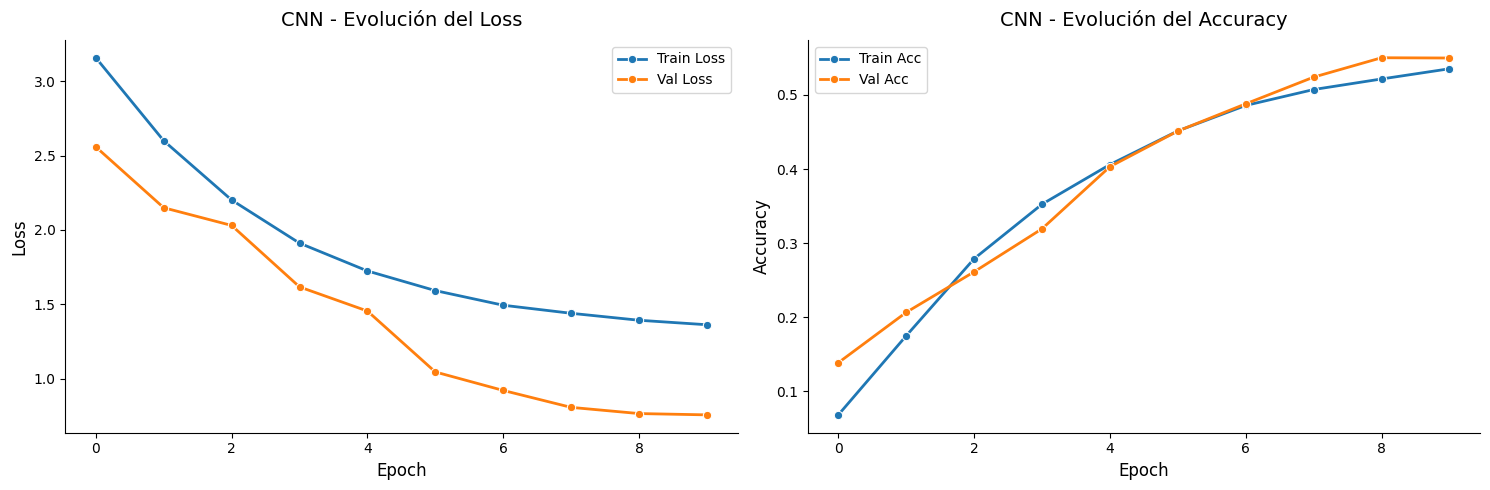

\n--- Reporte de Clasificación ---
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.90      0.83      0.87       183
  apu_nahasapeemapetilon       0.80      0.94      0.87       125
           barney_gumble       0.00      0.00      0.00        21
            bart_simpson       0.73      0.81      0.77       268
            carl_carlson       0.00      0.00      0.00        20
charles_montgomery_burns       0.82      0.73      0.77       239
            chief_wiggum       0.90      0.96      0.93       197
          comic_book_guy       0.79      0.70      0.74        94
          edna_krabappel       0.83      0.82      0.83        91
    groundskeeper_willie       1.00      0.08      0.15        24
           homer_simpson       0.82      0.90      0.86       449
           kent_brockman       0.86      0.87      0.87       100
        krusty_the_clown       0.87      0.97      0.92       241
           lenny_leonard       0.85     

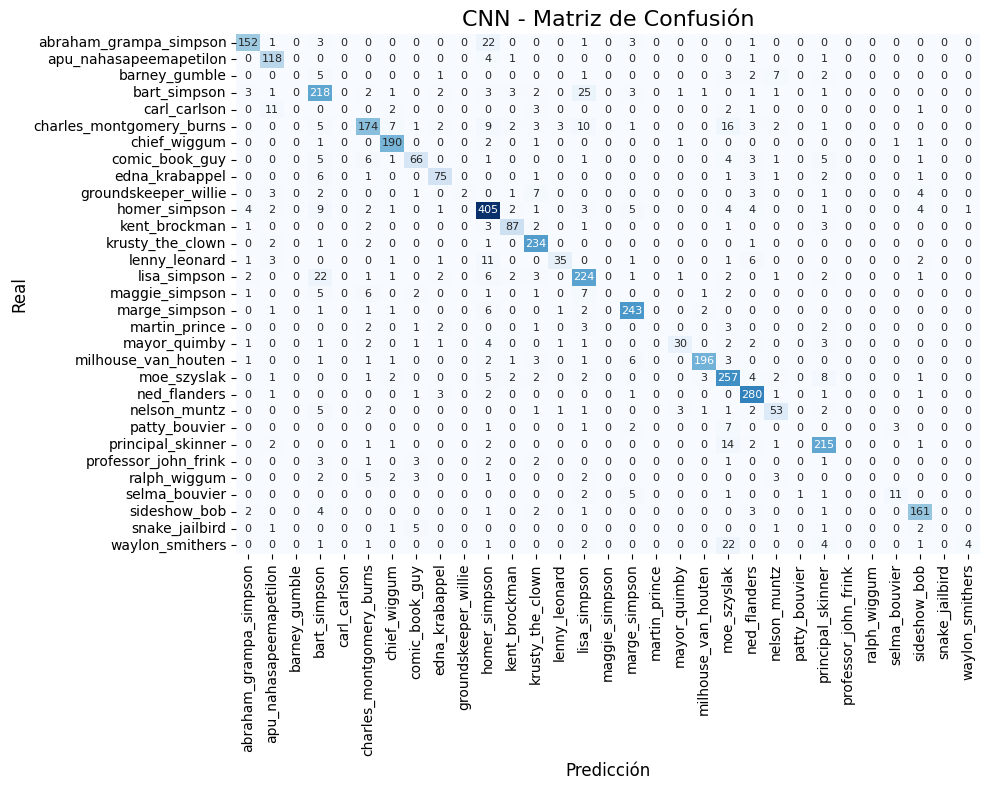

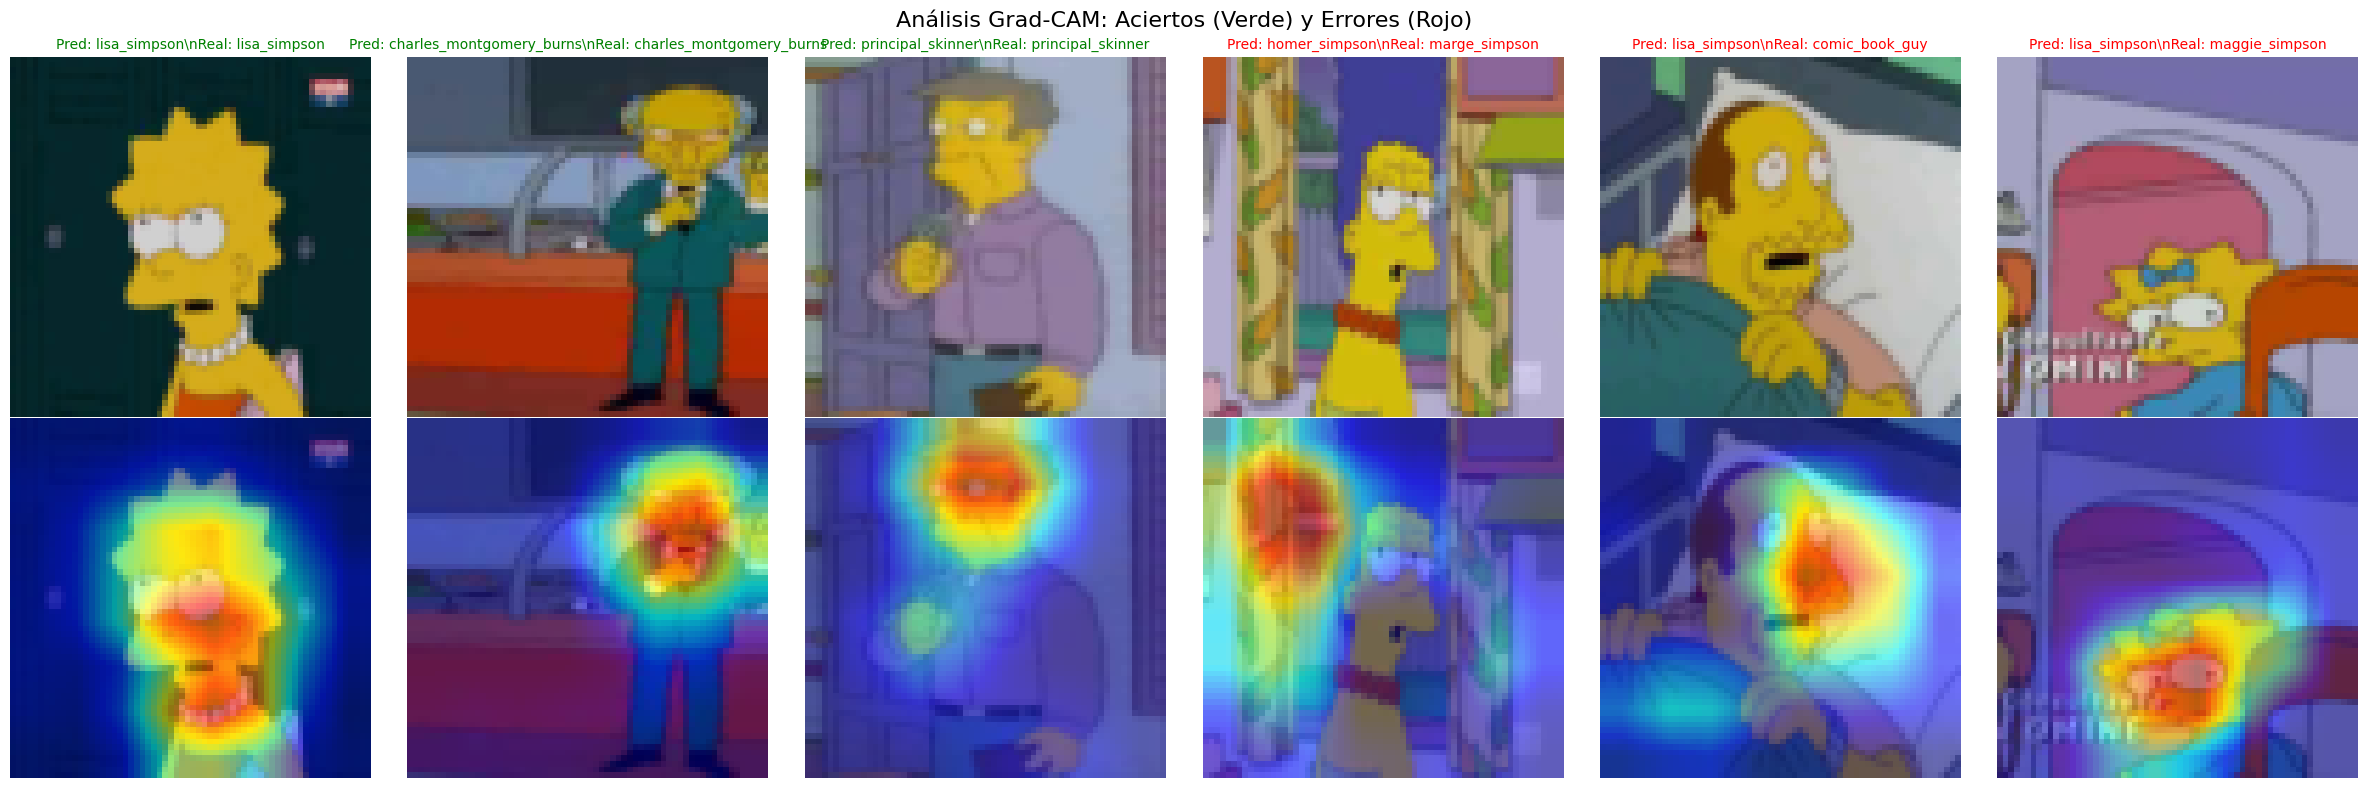

In [7]:
# Seleccionamos la última capa convolucional para Grad-CAM
target_layer = lightning_model.model.features[-2]

# Evaluar de forma unificada
evaluate_model(
    model=lightning_model, 
    trainer=trainer, 
    datamodule=datamodule, 
    history=pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv").to_dict("records"),
    target_layer=target_layer,
    title="CNN"
)


Al analizar las métricas y el reporte de clasificación de nuestra primera iteración con la arquitectura CNN base, podemos extraer conclusiones clave que evidencian sus limitaciones actuales y justifican la transición a modelos más sofisticados:Nuestra arquitectura base esta completa

Desbalance de Clases: Observamos una disparidad enorme en el número de muestras por personaje. Clases mayoritarias como Homer Simpson (449) o Marge Simpson (258) alcanzan un F1-Score muy bueno (0.86 y 0.92 respectivamente). Sin embargo, el modelo falla estrepitosamente (F1-Score de 0.00) en casi todas las clases minoritarias, como Barney Gumble (21), Maggie Simpson (26), Ralph Wiggum (18) o Snake Jailbird (11). El modelo ha aprendido simplemente a ignorar estas clases y predecir estadísticamente las más comunes para minimizar la función de pérdida general, de ahí que el macro F1 sea tan bajo (0.57) respecto al accuracy ponderado (0.81).

Sub entrenamiento: Si miramos las curvas de evolución del Loss y Accuracy, se hace evidente que ambas métricas, especialmente en el conjunto de validación, seguían mostrando una tendencia a mejorar cuando el entrenamiento se detuvo. El Val Loss continuaba bajando y el Val Acc subiendo. Esto nos indica que el modelo no llegó a la convergencia y podría haber seguido aprendiendo con más épocas.

Simpleza de la Arquitectura Base: Nuestra CNN inicial carece de la profundidad y complejidad (filtros y capas de extracción de características) necesarias para diferenciar de manera fina entre 31 personajes distintos, algunos de los cuales comparten paletas de colores casi idénticas y estilos de dibujo muy similares. Un modelo simple extrae patrones básicos, pero es incapaz de hallar texturas complejas o relaciones espaciales sutiles que permitirían discriminar correctamente a personajes con pocos datos de ejemplo.

## Conclusiones